# Benchmarking Off-the-Shelf POS Tagging and Named Entity Recognition: NLTK vs SpaCy

## Project Overview

Pretrained taggers are often used without measuring how well they work on the target text. This project benchmarks two widely used, ready-to-use English pipelines against the annotated CoNLL-2003 news corpus:

- **NLTK**: averaged-perceptron POS tagger plus the maximum-entropy named-entity chunker.
- **spaCy**: the `en_core_web_sm` pipeline.

Both systems are scored on part-of-speech tags and on named entities, using entity-level precision, recall, and F1 that I implement from scratch. The error analysis breaks mistakes down by type and shows how all-caps headlines affect each system. Finally, the stronger pipeline is combined with VADER sentiment to measure the tone of sentences that mention specific people in IMDb movie reviews.

**Tools:** Python, NLTK, spaCy, Hugging Face `datasets`, pandas, matplotlib, seaborn.

## Objective

Quantify how accurate two off-the-shelf NLP pipelines are on POS tagging and NER, identify where and why each one fails, and then use the stronger pipeline in a small applied information-extraction task.

## Dataset

| Dataset | Use | Size used | Access |
|---|---|---|---|
| CoNLL-2003 English ([`conll2003`](https://huggingface.co/datasets/eriktks/conll2003)) | POS and NER evaluation | Test split: 3,453 sentences, 46,435 tokens | Hugging Face `datasets` |
| IMDb Large Movie Review Dataset ([`stanfordnlp/imdb`](https://huggingface.co/datasets/stanfordnlp/imdb)) | Applied pipeline | 3,000 reviews sampled from the test split | Hugging Face `datasets` |

CoNLL-2003 is built from Reuters news articles. The annotations are free for research use, but the underlying text is covered by the Reuters Corpus (RCV1) license. CoNLL-2003 labels entities as `PER`, `ORG`, `LOC`, and `MISC` in the BIO scheme. Its POS tags were assigned automatically by a tagger, not by human annotators, so POS results are reported as **agreement** with the reference tags rather than as true accuracy.

Both datasets download automatically on first use.

## Setup and Imports

In [ ]:
import re
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
from datasets import disable_progress_bars, load_dataset
from huggingface_hub.utils import logging as hf_logging
from nltk import download as nltk_download
from nltk import sent_tokenize
from nltk.chunk import ne_chunker
from nltk.data import find as nltk_find
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tag import PerceptronTagger
from spacy.tokens import Doc

RANDOM_SEED = 42
IMDB_SAMPLE_SIZE = 3_000
SYSTEM_COLORS = {"NLTK": "#eb6834", "spaCy": "#2a78d6"}

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)
disable_progress_bars()
hf_logging.set_verbosity_error()

for resource, package in [
    ("taggers/averaged_perceptron_tagger_eng", "averaged_perceptron_tagger_eng"),
    ("chunkers/maxent_ne_chunker_tab", "maxent_ne_chunker_tab"),
    ("corpora/words", "words"),
    ("sentiment/vader_lexicon.zip", "vader_lexicon"),
    ("tokenizers/punkt_tab", "punkt_tab"),
]:
    try:
        nltk_find(resource)
    except LookupError:
        nltk_download(package, quiet=True)

try:
    nlp = spacy.load("en_core_web_sm")
except OSError as error:
    raise OSError("Run: python -m spacy download en_core_web_sm") from error

NLTK's convenience functions `nltk.pos_tag()` and `nltk.ne_chunk()` reload their models from disk on every call. Loading the tagger and chunker once and reusing them makes NLTK about 200 times faster on this corpus (around one second per 500 sentences instead of several minutes).

In [ ]:
nltk_tagger = PerceptronTagger()
nltk_chunker = ne_chunker()

## Data Preparation

Both systems receive the **gold tokenization** from CoNLL-2003, so every score reflects tagging quality rather than differences in tokenization. spaCy accepts pre-tokenized input as a `Doc` built from a word list.

In [ ]:
conll_test = load_dataset("conll2003", split="test")
pos_names = conll_test.features["pos_tags"].feature.names
ner_names = conll_test.features["ner_tags"].feature.names

sentences = [
    {
        "tokens": row["tokens"],
        "gold_pos": [pos_names[i] for i in row["pos_tags"]],
        "gold_ner": [ner_names[i] for i in row["ner_tags"]],
    }
    for row in conll_test
    if row["tokens"] and row["tokens"][0] != "-DOCSTART-"
]


def is_all_caps(tokens):
    letters = [t for t in tokens if any(ch.isalpha() for ch in t)]
    return bool(letters) and all(t.upper() == t for t in letters)


for s in sentences:
    s["all_caps"] = is_all_caps(s["tokens"])

print(f"Sentences: {len(sentences):,} | tokens: {sum(len(s['tokens']) for s in sentences):,}")
print(f"All-caps sentences (headlines and sports results): {sum(s['all_caps'] for s in sentences):,}")

Sentences: 3,453 | tokens: 46,435
All-caps sentences (headlines and sports results): 578


In [ ]:
def bio_to_spans(tags):
    """Convert BIO tags to a set of (start, end, type) entity spans."""
    spans, start, entity_type = set(), None, None
    for i, tag in enumerate(tags + ["O"]):
        if tag == "O" or tag.startswith("B-") or (tag.startswith("I-") and tag[2:] != entity_type):
            if start is not None:
                spans.add((start, i, entity_type))
                start, entity_type = None, None
            if tag != "O":
                start, entity_type = i, tag[2:]
    return spans


for s in sentences:
    s["gold_spans"] = bio_to_spans(s["gold_ner"])

gold_entity_counts = Counter(span[2] for s in sentences for span in s["gold_spans"])
pd.Series(gold_entity_counts, name="gold entities").sort_values(ascending=False).to_frame().T

,LOC,ORG,PER,MISC
gold entities,1668,1661,1617,702


## Model Development

### Running both pipelines

Each system uses its own label set, so every label is mapped onto CoNLL's four types. Labels with no CoNLL equivalent (dates, numbers, money) are dropped, because CoNLL does not annotate them. NLTK has no category corresponding to `MISC` (nationalities, events, and similar).

In [ ]:
NLTK_TO_CONLL = {"PERSON": "PER", "ORGANIZATION": "ORG", "GPE": "LOC", "LOCATION": "LOC",
                 "GSP": "LOC", "FACILITY": "LOC"}
SPACY_TO_CONLL = {"PERSON": "PER", "ORG": "ORG", "GPE": "LOC", "LOC": "LOC", "FAC": "LOC",
                  "NORP": "MISC", "EVENT": "MISC", "PRODUCT": "MISC", "WORK_OF_ART": "MISC",
                  "LANGUAGE": "MISC", "LAW": "MISC"}


def run_nltk(tokens):
    tagged = nltk_tagger.tag(tokens)
    tree = nltk_chunker.parse(tagged)
    spans, position = set(), 0
    for node in tree:
        if hasattr(node, "label"):
            length = len(node.leaves())
            if node.label() in NLTK_TO_CONLL:
                spans.add((position, position + length, NLTK_TO_CONLL[node.label()]))
            position += length
        else:
            position += 1
    return [tag for _, tag in tagged], spans


for s in sentences:
    s["nltk_pos"], s["nltk_spans"] = run_nltk(s["tokens"])

spacy_docs = nlp.pipe((Doc(nlp.vocab, words=s["tokens"]) for s in sentences), batch_size=256)
for s, doc in zip(sentences, spacy_docs):
    s["spacy_pos"] = [t.tag_ for t in doc]
    s["spacy_spans"] = {(e.start, e.end, SPACY_TO_CONLL[e.label_]) for e in doc.ents if e.label_ in SPACY_TO_CONLL}

## Model Evaluation

### Part-of-speech tagging

Both systems output Penn Treebank tags, the same tag set CoNLL uses. spaCy's model, however, follows the newer OntoNotes conventions for a few tags: brackets are `-LRB-`/`-RRB-` instead of `(`/`)`, hyphens are `HYPH`, opening and closing quotes are distinguished, and prepositional *to* is `IN` rather than `TO`. These are notation differences, not tagging errors, so agreement is reported twice: raw, and after mapping both systems' output to a shared convention.

In [ ]:
HARMONIZE_TAGS = {"-LRB-": "(", "-RRB-": ")", "HYPH": ":", "``": '"', "''": '"', "TO": "IN", "NFP": ":"}


def harmonize(tag):
    return HARMONIZE_TAGS.get(tag, tag)


def pos_agreement(subset, system, harmonized=False):
    normalize = harmonize if harmonized else (lambda tag: tag)
    pairs = [(normalize(g), normalize(p)) for s in subset for g, p in zip(s["gold_pos"], s[f"{system}_pos"])]
    return np.mean([g == p for g, p in pairs])


groups = {
    "All sentences": sentences,
    "Mixed-case sentences": [s for s in sentences if not s["all_caps"]],
    "All-caps sentences": [s for s in sentences if s["all_caps"]],
}
pos_table = pd.DataFrame({
    (convention, system): {group: pos_agreement(subset, system.lower(), harmonized=(convention == "Harmonized"))
                           for group, subset in groups.items()}
    for convention in ["Raw", "Harmonized"]
    for system in ["NLTK", "spaCy"]
})
pos_table.round(3)

Raw        Harmonized       
                       NLTK  spaCy       NLTK  spaCy
All sentences         0.908  0.869      0.908  0.919
Mixed-case sentences  0.919  0.876      0.919  0.928
All-caps sentences    0.728  0.748      0.728  0.777

In [ ]:
def top_pos_confusions(system, n=8):
    confusions = Counter(
        (harmonize(g), harmonize(p)) for s in sentences
        for g, p in zip(s["gold_pos"], s[f"{system}_pos"]) if harmonize(g) != harmonize(p)
    )
    return pd.DataFrame(
        [{"Reference": g, "Predicted": p, "Count": c} for (g, p), c in confusions.most_common(n)]
    )


pd.concat({"NLTK": top_pos_confusions("nltk"), "spaCy": top_pos_confusions("spacy")}, axis=1)

NLTK                     spaCy                
  Reference Predicted Count Reference Predicted Count
0        CD        JJ   389       NNP        NN   347
1        NN       NNP   308        NN       NNP   290
2        JJ       NNP   196        JJ       NNP   182
3       NNP        NN   178        CD       NNP   176
4         "        NN   175        JJ        NN   156
5       NNP        JJ   174        CD        LS   119
6        NN        JJ   153       NNP        JJ   114
7        JJ        NN   146        NN        JJ   103

### Named entity recognition

An entity counts as correct only if both its boundaries **and** its type match the gold annotation exactly (the standard CoNLL criterion). Scores are micro-averaged over all entities.

In [ ]:
def entity_scores(subset, system, entity_types=None):
    """Exact-match precision, recall, and F1, optionally restricted to some entity types."""
    true_pos = false_pos = false_neg = 0
    for s in subset:
        gold, pred = s["gold_spans"], s[f"{system}_spans"]
        if entity_types:
            gold = {e for e in gold if e[2] in entity_types}
            pred = {e for e in pred if e[2] in entity_types}
        true_pos += len(gold & pred)
        false_pos += len(pred - gold)
        false_neg += len(gold - pred)
    precision = true_pos / (true_pos + false_pos) if true_pos + false_pos else 0.0
    recall = true_pos / (true_pos + false_neg) if true_pos + false_neg else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"Precision": precision, "Recall": recall, "F1": f1}


ner_rows = []
for system in ["NLTK", "spaCy"]:
    for label, types in [("All types", None), ("PER", {"PER"}), ("ORG", {"ORG"}),
                         ("LOC", {"LOC"}), ("MISC", {"MISC"}), ("PER + ORG + LOC", {"PER", "ORG", "LOC"})]:
        ner_rows.append({"System": system, "Entity type": label, **entity_scores(sentences, system.lower(), types)})

ner_table = pd.DataFrame(ner_rows).set_index(["Entity type", "System"]).unstack("System").round(3)
ner_table

Precision        Recall            F1       
System               NLTK  spaCy   NLTK  spaCy   NLTK  spaCy
Entity type                                                 
All types           0.488  0.656  0.466  0.545  0.477  0.595
LOC                 0.516  0.770  0.704  0.730  0.595  0.749
MISC                0.000  0.675  0.000  0.564  0.000  0.614
ORG                 0.321  0.430  0.253  0.310  0.283  0.360
PER                 0.576  0.716  0.641  0.588  0.606  0.646
PER + ORG + LOC     0.488  0.653  0.532  0.542  0.509  0.593

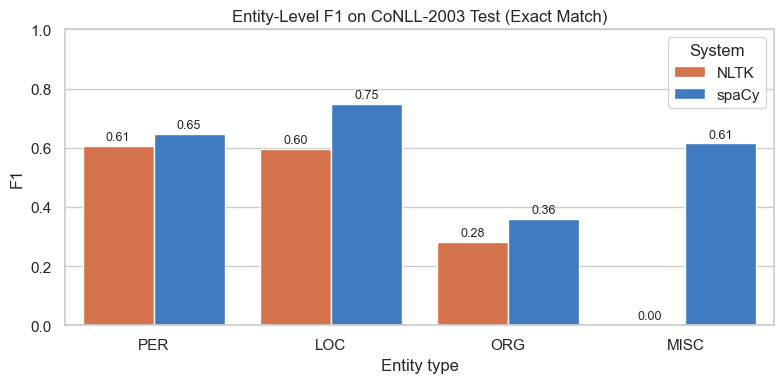

In [ ]:
f1_by_type = pd.DataFrame(ner_rows).query("`Entity type` in ['PER', 'ORG', 'LOC', 'MISC']")

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=f1_by_type, x="Entity type", y="F1", hue="System", palette=SYSTEM_COLORS,
            order=["PER", "LOC", "ORG", "MISC"], ax=ax)
ax.set_title("Entity-Level F1 on CoNLL-2003 Test (Exact Match)")
ax.set_xlabel("Entity type")
ax.set_ylabel("F1")
ax.set_ylim(0, 1)
ax.legend(title="System", loc="upper right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, padding=2)
plt.tight_layout()
plt.show()

## Error Analysis

### 1. What kind of mistakes?

Every gold entity is placed in exactly one category:

- **Exact match**: correct boundaries and correct type.
- **Wrong type**: correct boundaries, wrong label.
- **Boundary error**: overlaps a predicted entity whose boundaries differ (for example, *Chicago* instead of *Chicago Bulls*).
- **Missed**: no overlapping prediction at all.

In [ ]:
def categorize_gold_entities(system):
    categories = Counter()
    for s in sentences:
        predicted = s[f"{system}_spans"]
        predicted_boundaries = {(start, end) for start, end, _ in predicted}
        for start, end, entity_type in s["gold_spans"]:
            if (start, end, entity_type) in predicted:
                categories["Exact match"] += 1
            elif (start, end) in predicted_boundaries:
                categories["Wrong type"] += 1
            elif any(p_start < end and start < p_end for p_start, p_end, _ in predicted):
                categories["Boundary error"] += 1
            else:
                categories["Missed"] += 1
    return categories


error_breakdown = pd.DataFrame({system: categorize_gold_entities(system.lower()) for system in ["NLTK", "spaCy"]})
error_breakdown = error_breakdown.loc[["Exact match", "Wrong type", "Boundary error", "Missed"]]
(error_breakdown / error_breakdown.sum()).round(3)

,NLTK,spaCy
Exact match,0.466,0.545
Wrong type,0.217,0.142
Boundary error,0.124,0.125
Missed,0.193,0.188


In [ ]:
def type_confusions(system):
    confusions = Counter()
    for s in sentences:
        predicted = {(start, end): t for start, end, t in s[f"{system}_spans"]}
        for start, end, gold_type in s["gold_spans"]:
            if (start, end) in predicted and predicted[(start, end)] != gold_type:
                confusions[(gold_type, predicted[(start, end)])] += 1
    return pd.Series(confusions).sort_values(ascending=False).head(6)


pd.concat({"NLTK": type_confusions("nltk"), "spaCy": type_confusions("spacy")}, axis=1).fillna(0).astype(int).rename_axis(["Gold", "Predicted"])

NLTK  spaCy
Gold Predicted             
MISC LOC         309      0
ORG  LOC         198    185
     PER         167    143
LOC  ORG         166    104
     PER         111      0
PER  LOC          90     37
     ORG           0    161
MISC ORG           0     41

### 2. Effect of capitalization

About one in six CoNLL test sentences is an all-caps headlines or sports results ("SOCCER - JAPAN GET LUCKY WIN"). Both systems rely heavily on capitalization as an entity cue, which all-caps text removes.

In [ ]:
caps_rows = []
for group, subset in groups.items():
    for system in ["NLTK", "spaCy"]:
        caps_rows.append({"Group": group, "System": system, **entity_scores(subset, system.lower(), {"PER", "ORG", "LOC"})})

caps_table = pd.DataFrame(caps_rows)
caps_table.pivot(index="Group", columns="System", values="F1").loc[list(groups)].round(3).rename_axis(
    "F1 on PER + ORG + LOC", axis=1)

F1 on PER + ORG + LOC,NLTK,spaCy
Group,,
All sentences,0.509,0.593
Mixed-case sentences,0.535,0.616
All-caps sentences,0.318,0.384


### 3. Example sentences

A side-by-side view of the gold and predicted entities in a few test sentences.

In [ ]:
def describe_spans(tokens, spans):
    return "; ".join(f"{' '.join(tokens[a:b])} [{t}]" for a, b, t in sorted(spans)) or "-"


example_rows = []
for index in [2, 3, 12, 40, 95]:
    s = sentences[index]
    example_rows.append({
        "Sentence": " ".join(s["tokens"]),
        "Gold": describe_spans(s["tokens"], s["gold_spans"]),
        "NLTK": describe_spans(s["tokens"], s["nltk_spans"]),
        "spaCy": describe_spans(s["tokens"], s["spacy_spans"]),
    })
with pd.option_context("display.max_colwidth", 200):
    display(pd.DataFrame(example_rows))

,Sentence,Gold,NLTK,spaCy
0,"AL-AIN , United Arab Emirates 1996-12-06",AL-AIN [LOC]; United Arab Emirates [LOC],AL-AIN [LOC]; United Arab [LOC],AL-AIN [ORG]; United Arab Emirates [LOC]
1,Japan began the defence of their Asian Cup title with a lucky 2-1 win against Syria in a Group C championship match on Friday .,Japan [LOC]; Asian Cup [MISC]; Syria [LOC],Japan [LOC]; Asian [LOC]; Syria [LOC],Japan [LOC]; Asian Cup [MISC]; Syria [LOC]; Group C [ORG]
2,Defender Hassan Abbas rose to intercept a long ball into the area in the 84th minute but only managed to divert it into the top corner of Bitar 's goal .,Hassan Abbas [PER]; Bitar [PER],Defender [PER]; Hassan Abbas [PER]; Bitar [PER],Defender Hassan Abbas [PER]; Bitar [PER]
3,Syria had taken the lead from their first serious attack in the seventh minute .,Syria [LOC],Syria [LOC],Syria [LOC]
4,one-day cricket international between Pakistan and New Zealand,Pakistan [LOC]; New Zealand [LOC],Pakistan [LOC]; New Zealand [LOC],Pakistan [LOC]; New Zealand [LOC]


## Applied Pipeline: Sentiment Toward People Mentioned in Movie Reviews

The spaCy pipeline is the stronger of the two, so it is used in a small applied task. For each IMDb review:

1. Remove HTML line breaks and split the text into sentences.
2. Find `PERSON` entities with spaCy.
3. Score each sentence that mentions a person with VADER.

This produces a sentiment score for each mention instead of one score for the whole review.

A useful first check is whether the sentences that mention people point the same way as the review's overall label. If they do, mention-level sentiment carries real signal about how the reviewer feels.

In [ ]:
imdb_sample = (load_dataset("stanfordnlp/imdb", split="test")
               .shuffle(seed=RANDOM_SEED).select(range(IMDB_SAMPLE_SIZE)).to_pandas())
imdb_sample["text"] = imdb_sample["text"].str.replace(r"<br\s*/?>", " ", regex=True).str.replace(r"\s+", " ", regex=True)

vader = SentimentIntensityAnalyzer()
mention_rows = []
review_scores = []
for review_id, doc in enumerate(nlp.pipe(imdb_sample["text"], batch_size=64)):
    label = int(imdb_sample.at[review_id, "label"])
    review_scores.append(vader.polarity_scores(doc.text)["compound"])
    for sentence in doc.sents:
        people = {ent.text.strip() for ent in sentence.ents if ent.label_ == "PERSON"}
        if not people:
            continue
        sentence_score = vader.polarity_scores(sentence.text)["compound"]
        for person in people:
            mention_rows.append({"review_id": review_id, "person": person, "label": label,
                                 "sentence_score": sentence_score, "sentence": sentence.text})

mentions = pd.DataFrame(mention_rows)
imdb_sample["review_score"] = review_scores
print(f"Reviews: {len(imdb_sample):,} | person mentions: {len(mentions):,} | "
      f"reviews with at least one person: {mentions['review_id'].nunique():,}")

Reviews: 3,000 | person mentions: 13,302 | reviews with at least one person: 2,401


In [ ]:
# Does the mean sentiment of person-mention sentences agree with the review label?
per_review = mentions.groupby("review_id").agg(label=("label", "first"), mention_score=("sentence_score", "mean"))
per_review["review_score"] = imdb_sample.loc[per_review.index, "review_score"]

agreement = pd.DataFrame({
    "Agreement with review label": [
        ((per_review["mention_score"] >= 0).astype(int) == per_review["label"]).mean(),
        ((per_review["review_score"] >= 0).astype(int) == per_review["label"]).mean(),
    ]
}, index=["Mean VADER of sentences that mention people", "VADER on the whole review"])
agreement.round(3)

,Agreement with review label
Mean VADER of sentences that mention people,0.615
VADER on the whole review,0.692


In [ ]:
# The most frequent raw PERSON strings expose NER errors that would distort any aggregate
mentions.groupby("person")["review_id"].nunique().nlargest(12).rename("reviews").to_frame().T

person,gore,Oscar,Shakespeare,Jack,John Wayne,Hitler,David,John,Sam,Jesus,Joe,Spielberg
reviews,73,56,28,27,16,15,14,14,14,13,13,13


Several of the most frequent "people" are model errors. *gore* (the horror-film term, lowercase) is tagged as a person, and so is *Oscar* (the award). Single first names (*Jack*, *John*) are ambiguous across reviews. To reduce this noise, the aggregation below keeps only **capitalized, multi-word names**, such as *John Wayne*, mentioned in at least five reviews.

In [ ]:
is_full_name = mentions["person"].str.fullmatch(r"[A-Z][\w.'-]+(?: [A-Z][\w.'-]+)+")
person_summary = (
    mentions[is_full_name].groupby("person")
    .agg(reviews=("review_id", "nunique"), mean_mention_sentiment=("sentence_score", "mean"),
         share_positive_reviews=("label", "mean"))
    .query("reviews >= 5")
    .sort_values("reviews", ascending=False)
)
person_summary.head(12).round(2)

,reviews,mean_mention_sentiment,share_positive_reviews
person,,,
John Wayne,16,-0.04,0.47
Bruce Willis,11,0.20,0.27
Susan Sarandon,11,0.43,0.85
Sean Penn,11,0.31,0.85
Donald Sutherland,10,0.27,0.60
Dennis Hopper,9,0.02,0.45
Michael Jackson,9,0.04,0.67
Julianne Moore,8,0.12,0.25
Ed Wood,8,-0.35,0.00


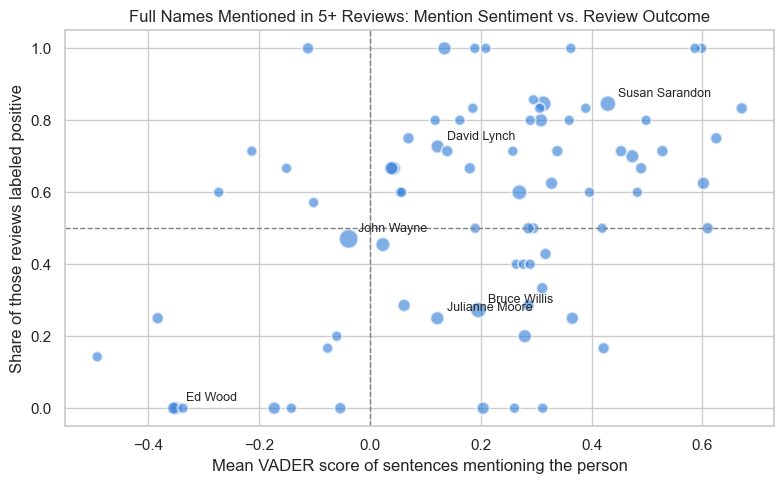

Spearman correlation: 0.38 (n = 76 people)


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(person_summary["mean_mention_sentiment"], person_summary["share_positive_reviews"],
           s=person_summary["reviews"] * 12, color="#2a78d6", alpha=0.6, edgecolor="white", linewidth=1.5)
for name in ["John Wayne", "Susan Sarandon", "Bruce Willis", "Ed Wood", "David Lynch", "Julianne Moore"]:
    row = person_summary.loc[name]
    ax.annotate(name, (row["mean_mention_sentiment"], row["share_positive_reviews"]),
                textcoords="offset points", xytext=(7, 5), fontsize=9)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Full Names Mentioned in 5+ Reviews: Mention Sentiment vs. Review Outcome")
ax.set_xlabel("Mean VADER score of sentences mentioning the person")
ax.set_ylabel("Share of those reviews labeled positive")
plt.tight_layout()
plt.show()

print(f"Spearman correlation: {person_summary['mean_mention_sentiment'].corr(person_summary['share_positive_reviews'], method='spearman'):.2f} "
      f"(n = {len(person_summary)} people)")

## Key Findings

| Metric (CoNLL-2003 test) | NLTK | spaCy `en_core_web_sm` |
|---|---|---|
| POS agreement, raw tags | 0.908 | 0.869 |
| POS agreement, harmonized tag conventions | 0.908 | **0.919** |
| NER F1, all four types | 0.477 | **0.595** |
| NER F1, PER + ORG + LOC only | 0.509 | **0.593** |
| NER F1 on all-caps sentences (PER + ORG + LOC) | 0.318 | 0.384 |

- **Notation differences can reverse a comparison.** Raw POS agreement makes spaCy look 4 points worse than NLTK. After mapping the bracket, hyphen, quote, and *to* conventions, spaCy is 1 point better. Without that check, the raw comparison would have given the wrong conclusion.
- **spaCy is the stronger NER system, but neither is close to state of the art** (fine-tuned models exceed 0.90 F1 on this benchmark). spaCy wins on every entity type and is the only one that can produce `MISC`.
- **Organizations are the hardest type for both** (F1 0.28 and 0.36). They are most often mislabeled as locations or people. The most frequent ORG→LOC errors are sports clubs named after their cities (*Barcelona*, *PHILADELPHIA*, *Newcastle*, *Milan*).
- **Most NLTK errors are type errors** (21.7% of gold entities get the right span but the wrong label), mainly nationality adjectives (*French*, *Italian*, *German*), which CoNLL labels `MISC` and NLTK labels as places. spaCy's errors are more evenly split, and both miss about 19% of entities entirely.
- **Capitalization is a key cue for both systems.** On the 578 all-caps headline and results sentences, F1 drops by about 0.22 points for each system, and POS agreement drops by 15–19 points.
- **In the applied pipeline, NER errors propagate.** On IMDb reviews, the most frequent "person" is *gore* (73 reviews) and the second is *Oscar*. After restricting to capitalized full names, mention-level sentiment correlates moderately with review outcomes (Spearman 0.38 across 76 people). *Ed Wood*, a director known for famously bad films, is mentioned only in negative reviews.
- **Sentences that mention people are a weaker signal than the full review.** Their average VADER score matches the review label 61.5% of the time, vs. 69.2% for whole-review VADER. Much of what reviewers say about actors and directors is descriptive rather than evaluative.

## Limitations

- CoNLL-2003 is 1990s Reuters news. Scores on other domains (social media, fiction, reviews) will differ
- Both systems are evaluated as shipped. spaCy's larger models (`en_core_web_lg`, `en_core_web_trf`) and fine-tuned transformers score much higher on CoNLL-2003, but they are slower and require larger downloads.
- The label mapping is approximate. For example, CoNLL tags *German* (adjective) as `MISC`, while NLTK has no comparable category, so NLTK's MISC recall is zero by construction.
- Mention-level sentiment uses whole-sentence VADER scores. A sentence such as "Unlike Smith, Jones was terrible" assigns the same score to both people.

## Next Steps

- Add `en_core_web_trf` and a fine-tuned BERT NER model to the benchmark to measure the accuracy/speed trade-off.
- Use dependency parsing to attach sentiment-bearing words to the specific entity they describe

## Attribution

- CoNLL-2003: Tjong Kim Sang, E. F., & De Meulder, F. (2003). *Introduction to the CoNLL-2003 Shared Task: Language-Independent Named Entity Recognition.* Text from the Reuters Corpus (RCV1)